In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

In [35]:
# 1. Load actual file(UK anglian 2025 ,water quality explorar)
df = pd.read_csv("observations.csv", low_memory=False)

In [36]:
print (df.columns.tolist())

['id', 'samplingPoint.notation', 'samplingPoint.prefLabel', 'samplingPoint.longitude', 'samplingPoint.latitude', 'samplingPoint.region', 'samplingPoint.area', 'samplingPoint.subArea', 'samplingPoint.samplingPointStatus', 'samplingPoint.samplingPointType', 'phenomenonTime', 'samplingPurpose', 'sampleMaterialType', 'determinand.notation', 'determinand.prefLabel', 'result', 'unit']


In [38]:

# for Nitrate measurements
# This targets the 'Nitrate as N' rows 
nitrate_df = df[df['determinand.prefLabel'].str.contains('Nitrate', na=False, case=False)]



In [39]:
#  Keep only the essential columns for Machine Learning model
ml_columns = [
    'samplingPoint.longitude',  # Feature 1: Longitude
    'samplingPoint.latitude',   # Feature 2: Latitude
    'phenomenonTime',           # Feature 3: Date/Time of sample for seasonal fluctuation
    'result'                    # Target Variable: Concentration
]


In [26]:

cleaned_data = nitrate_df[ml_columns].dropna()

In [27]:
# 4. Quick inspection
print(f"Success! Cleaned dataset has {cleaned_data.shape[0]} rows ready for ML.")
print(cleaned_data.head())

Success! Cleaned dataset has 8565 rows ready for ML.
    samplingPoint.longitude  samplingPoint.latitude       phenomenonTime  \
18                  -1.0707                 52.0673  2025-01-31T11:21:00   
31                  -1.0707                 52.0673  2025-02-14T13:20:00   
44                  -1.0707                 52.0673  2025-03-06T09:43:00   
57                  -1.0707                 52.0673  2025-04-10T11:55:00   
70                  -1.0707                 52.0673  2025-05-06T14:09:00   

   result  
18   3.18  
31   5.07  
44   4.78  
57   6.47  
70   6.42  


In [41]:
# Replace 'cleaned_observations.csv' with your actual cleaned file name
cleaned_data.to_csv('cleaned_observations.csv',index=False)
df = pd.read_csv("cleaned_observations.csv")

In [48]:
# 2. FEATURE ENGINEERING (Handling the Date)
# Convert the phenomenonTime string into a datetime object
df['phenomenonTime'] = pd.to_datetime(df['phenomenonTime'])
# Extract numerical components that the model can understand
df['Year'] = df['phenomenonTime'].dt.year
df['Month'] = df['phenomenonTime'].dt.month
df['DayOfYear'] = df['phenomenonTime'].dt.dayofyear

# 1.In environmental chemistry, when a pollutant concentration is below what the laboratory equipment can reliably detect,
#they don't record it as 0. Instead, they log it as a string text like <0.196 (meaning "less than the detection limit of 0.196").
#Because it contains the text character <, Python reads that entire column as words (strings) rather than numbers.
#XGBoost cannot do math on words, which causes the model to crash during training.
#Remove the '<' sign from any values in the result column
df['result'] = df['result'].astype(str).str.replace('<', '', regex=False)
df.tail()

,samplingPoint.longitude,samplingPoint.latitude,phenomenonTime,result,Year,Month,DayOfYear
8560,1.1287,52.3202,2025-01-21 12:13:00,22.7,2025,1,21
8561,1.1287,52.3202,2025-02-13 13:19:00,20,2025,2,44
8562,1.1287,52.3202,2025-03-05 10:55:00,23.6,2025,3,64
8563,0.4739,51.9864,2025-02-13 09:12:00,0.376,2025,2,44
8564,0.4739,51.9864,2025-07-10 13:41:00,0.196,2025,7,191


In [50]:
# 2. Convert the entire column to clean numbers (floats)
# errors='coerce' turns any unfixable text into a blank space (NaN)
df['result'] = pd.to_numeric(df['result'], errors='coerce')
# 3. Drop any rows that became blank to keep the data pristine
df = df.dropna(subset=['result'])

In [51]:
# 3. DEFINE FEATURES (X) AND TARGET (y)
# ==========================================
# Features: What the model uses to learn (Location + Time)
features = ['samplingPoint.longitude', 'samplingPoint.latitude', 'Year', 'Month', 'DayOfYear']
X = df[features]

# Target: What the model is trying to predict (Nitrate concentration)
y = df['result']


# Split data: 80% for training the model, 20% to test its accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [52]:

# 4. INITIALIZE AND TRAIN THE MODEL
# ==========================================
print("Training the XGBoost Regressor model...")
model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42)
model.fit(X_train, y_train)

# ==========================================
# 5. EVALUATE MODEL PERFORMANCE
# ==========================================
# Predict on the unseen test data
y_pred = model.predict(X_test)

# Calculate standard environmental geology metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation Results ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} mg/L")
print(f"R-squared Score (R²): {r2:.4f}")

Training the XGBoost Regressor model...

--- Model Evaluation Results ---
Root Mean Squared Error (RMSE): 15.4947 mg/L
R-squared Score (R²): 0.3399


In [ ]:
#In environmental geology, nitrate transport is heavily dictated by variables we haven't given the model yet:soil permeability,bedrock type, agricultural fertilizer application rates, and rainfall.
#For a baseline model using only position and time, a score of $0.34$ is a completely normal


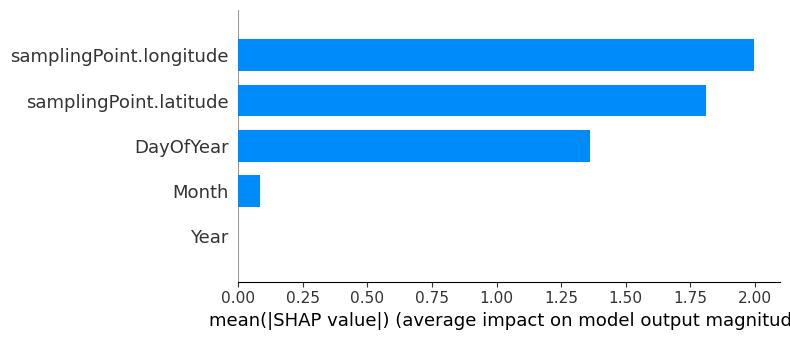

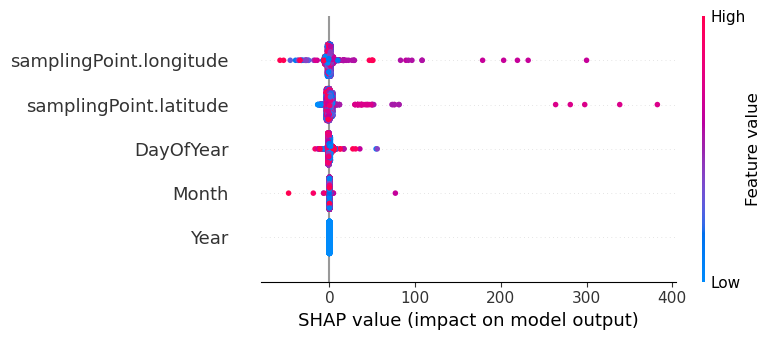

In [54]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP explainer with your trained XGBoost model
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)

# 2. Generate a Summary Plot (Feature Importance)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train, plot_type="bar")

# 3. Generate a Beeswarm Plot (Shows positive/negative impacts)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train)